# Value of Information in Soil Measurement Acquisition for Site-Specific Fertilizer Recommendation

This notebook is the computational source of truth for the workshop paper. The primary benchmark uses the public `agridat::ortiz.tomato.covs` multi-environment dataset. Candidate soil measurements are pH, organic matter (OM), phosphorus (P), and potassium (K); recorded extra N, P, and K fertilizer amounts are treated as historical reference actions rather than causal agronomic optima.

The workflow performs exhaustive soil-subset evaluation, leave-one-environment-out validation, paired bootstrap value-of-information intervals, exact and sequential budgeted acquisition, public laboratory-menu illustration, and ridge-regularization sensitivity. The repository bundles the public dataset, so the primary result path has no network dependency.

In [1]:
from __future__ import annotations
import itertools, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import LeaveOneOut

ROOT = Path.cwd()
DATA_DIR = ROOT / "data"
RESULTS = ROOT / "results"
FIGURES = ROOT / "figures"
for p in [DATA_DIR, RESULTS, FIGURES]:
    p.mkdir(parents=True, exist_ok=True)

DATA = DATA_DIR / "ortiz_tomato_covs.csv"
DATA_URL = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/refs/heads/master/csv/agridat/ortiz.tomato.covs.csv"

SEED = 20260831
# Primary free context excludes latitude/longitude because the public table contains
# a geographically inconsistent longitude for E05; no inferred coordinate correction is used.
BASE = ["Irr", "Trim", "Driv"]
SOIL = ["pH", "OM", "P", "K"]
TARGETS = ["ExN", "ExP", "ExK"]
ALPHA = 10.0

print("Repository root:", ROOT)
print("Primary free context:", BASE)
print("NumPy", np.__version__, "pandas", pd.__version__)

Repository root: /mnt/data/soil-measurement-acquisition-final
Primary free context: ['Irr', 'Trim', 'Driv']
NumPy 2.3.5 pandas 2.2.3


## 1. Public data and data-quality audit

The source contains 18 Latin American tomato environments. `ExN`, `ExP`, and `ExK` denote recorded extra nutrient amounts (kg/ha); `pH`, `OM`, `P`, and `K` are candidate soil measurements.

Latitude and longitude are preserved in the bundled public file but excluded from the primary predictive baseline. This avoids introducing an inferred correction for the visibly inconsistent E05 longitude and prevents the headline measurement ranking from depending on that anomalous coordinate.

In [2]:
if not DATA.exists():
    print("Bundled dataset not found; downloading the public agridat mirror.")
    pd.read_csv(DATA_URL).to_csv(DATA, index=False)

df = pd.read_csv(DATA)
assert len(df) == 18
assert set(BASE + SOIL + TARGETS).issubset(df.columns)

print("Rows, columns:", df.shape)
print("E05 public coordinate entry:")
display(df.loc[df["env"].eq("E05"), ["env", "Lat", "Long"]])

SCALE = (df[TARGETS].quantile(.75) - df[TARGETS].quantile(.25)).replace(0, 1.0)
scale_vec = SCALE.to_numpy(float)
print("Target IQRs (kg/ha):")
display(SCALE.to_frame("IQR"))

Rows, columns: (18, 20)
E05 public coordinate entry:


,env,Lat,Long
1,E05,15.0,9.2


Target IQRs (kg/ha):


,IQR
ExN,63.25
ExP,101.25
ExK,39.50


## 2. Decision loss and exhaustive subset benchmark

For a soil-measurement subset $S$, a standardized multi-output ridge model estimates the historical NPK reference action from the free management context plus $S$. Each environment is held out once. Action loss averages absolute N, P, and K errors after normalization by the corresponding target interquartile range. All $2^4=16$ subsets are evaluated on identical folds.

In [3]:
def key_for(bits):
    bits = set(bits)
    ordered = [x for x in SOIL if x in bits]
    return "none" if not ordered else "+".join(ordered)

def cv_subset(subset, alpha=ALPHA):
    features = BASE + list(subset)
    X = df[features].to_numpy(float)
    Y = df[TARGETS].to_numpy(float)
    preds = np.zeros_like(Y, dtype=float)
    for train, test in LeaveOneOut().split(X):
        model = Pipeline([
            ("scale", StandardScaler()),
            ("ridge", Ridge(alpha=alpha)),
        ])
        model.fit(X[train], Y[train])
        preds[test] = model.predict(X[test])
    per_env = np.mean(np.abs(Y - preds) / scale_vec, axis=1)
    per_target = np.mean(np.abs(Y - preds) / scale_vec, axis=0)
    return preds, per_env, per_target

records, lossstore = [], {}
for r in range(5):
    for subset in itertools.combinations(SOIL, r):
        key = key_for(subset)
        _, env_loss, target_loss = cv_subset(subset)
        lossstore[key] = env_loss
        records.append({
            "subset": key, "k": r,
            "loss_mean": env_loss.mean(),
            "loss_median": np.median(env_loss),
            "loss_se": env_loss.std(ddof=1) / np.sqrt(len(env_loss)),
            "nmae_N": target_loss[0], "nmae_P": target_loss[1], "nmae_K": target_loss[2],
        })

subset_results = pd.DataFrame(records).sort_values(["k", "loss_mean"]).reset_index(drop=True)
subset_results.to_csv(RESULTS / "subset_results.csv", index=False)
loss_map = dict(zip(subset_results.subset, subset_results.loss_mean))
oracle = subset_results.loc[subset_results.groupby("k")["loss_mean"].idxmin()].sort_values("k").copy()
oracle["change_vs_baseline_pct"] = 100 * (loss_map["none"] - oracle["loss_mean"]) / loss_map["none"]
oracle.to_csv(RESULTS / "oracle_by_k.csv", index=False)

print("All 16 subsets:")
display(subset_results)
print("Exact best subset by measurement count:")
display(oracle[["k", "subset", "loss_mean", "change_vs_baseline_pct"]])

All 16 subsets:


,subset,k,loss_mean,loss_median,loss_se,nmae_N,nmae_P,nmae_K
0,none,0,1.442896,1.043859,0.418726,1.251630,1.210479,1.866578
1,OM,1,1.392693,1.034395,0.407739,1.164471,1.234201,1.779407
2,K,1,1.443421,1.031815,0.418213,1.239026,1.235552,1.855685
3,P,1,1.463926,1.034850,0.417472,1.302930,1.187184,1.901665
4,pH,1,1.499495,1.082499,0.420352,1.258048,1.248966,1.991469
5,OM+K,2,1.416841,0.972908,0.405762,1.159349,1.303808,1.787365
6,pH+OM,2,1.434009,1.082795,0.411736,1.161097,1.276823,1.864106
7,OM+P,2,1.436788,1.079568,0.404914,1.254181,1.179388,1.876796
8,P+K,2,1.442299,1.007407,0.420184,1.258943,1.212026,1.855928
9,pH+K,2,1.514946,1.112900,0.419183,1.267001,1.277845,1.999993


Exact best subset by measurement count:


,k,subset,loss_mean,change_vs_baseline_pct
0,0,none,1.442896,0.000000
1,1,OM,1.392693,3.479326
5,2,OM+K,1.416841,1.805758
11,3,OM+P+K,1.446093,-0.221572
15,4,pH+OM+P+K,1.494375,-3.567789


## 3. Sequential value of information and uncertainty

Singleton value of information is the paired reduction in held-out normalized NPK action loss relative to the no-soil baseline. Uncertainty is estimated with 10,000 paired bootstrap resamples over the 18 held-out environments.

The equal-cost sequential policy acquires the feasible measurement with the largest positive marginal VOI. Acquisition stops whenever the best remaining marginal VOI is non-positive.

In [4]:
base_loss = loss_map["none"]

# Equal-cost positive-VOI greedy path.
chosen, greedy_rows = [], []
step = 0
while True:
    key = key_for(chosen)
    current = loss_map[key]
    greedy_rows.append({"step": step, "k": len(chosen), "subset": key, "loss_mean": current})
    candidates = []
    for j in SOIL:
        if j in chosen:
            continue
        new_key = key_for(chosen + [j])
        new_loss = loss_map[new_key]
        candidates.append((current - new_loss, j, new_loss))
    if not candidates:
        break
    candidates.sort(key=lambda z: (-z[0], SOIL.index(z[1])))
    if candidates[0][0] <= 0:
        break
    chosen.append(candidates[0][1])
    step += 1

greedy_equal = pd.DataFrame(greedy_rows)
greedy_equal.to_csv(RESULTS / "greedy_equal_cost.csv", index=False)

# Mean random-order curve across all 24 measurement orders.
permutations = list(itertools.permutations(SOIL))
random_rows = []
for k in range(5):
    values = [loss_map[key_for(perm[:k])] for perm in permutations]
    random_rows.append({"k": k, "loss_mean": np.mean(values), "loss_sd": np.std(values, ddof=1)})
random_order = pd.DataFrame(random_rows)
random_order.to_csv(RESULTS / "random_order.csv", index=False)

# Paired bootstrap over held-out environments; independent deterministic stream per measurement.
voi_rows = []
for mi, j in enumerate(SOIL):
    rng = np.random.default_rng(SEED + mi)
    delta = lossstore["none"] - lossstore[j]
    idx = rng.integers(0, len(delta), size=(10000, len(delta)))
    boot = delta[idx].mean(axis=1)
    lo, hi = np.quantile(boot, [.025, .975])
    voi_rows.append({
        "measurement": j,
        "mean_voi": delta.mean(),
        "ci_low": lo, "ci_high": hi,
        "positive_env_fraction": np.mean(delta > 0),
    })
voi = pd.DataFrame(voi_rows).sort_values("mean_voi", ascending=False).reset_index(drop=True)
voi.to_csv(RESULTS / "singleton_voi_bootstrap.csv", index=False)

print("Positive-VOI equal-cost path:")
display(greedy_equal)
print("Singleton VOI:")
display(voi)

Positive-VOI equal-cost path:


,step,k,subset,loss_mean
0,0,0,none,1.442896
1,1,1,OM,1.392693


Singleton VOI:


,measurement,mean_voi,ci_low,ci_high,positive_env_fraction
0,OM,0.050203,-0.123492,0.207930,0.500000
1,K,-0.000525,-0.044201,0.055027,0.333333
2,P,-0.021030,-0.070761,0.019329,0.500000
3,pH,-0.056599,-0.105531,-0.019623,0.055556


## 4. Heterogeneous costs and exact budget oracle

Each candidate receives a relative cost in $\{0.5,1,2,4\}$. All $4^4=256$ cost vectors and every attainable subset-cost budget are evaluated, producing 2,612 cases. Exact enumeration supplies the budget oracle. The sequential comparator repeatedly maximizes positive marginal VOI divided by cost and stops if no feasible candidate has positive marginal VOI.

This stopping rule is essential: available budget is not a requirement to purchase a harmful measurement.

In [5]:
cost_grid = [0.5, 1.0, 2.0, 4.0]
subsets = []
for key, loss in loss_map.items():
    bits = [] if key == "none" else key.split("+")
    subsets.append((key, bits, loss))

cost_rows = []
for costs in itertools.product(cost_grid, repeat=4):
    cd = dict(zip(SOIL, costs))
    infos = [(key, sum(cd[b] for b in bits), loss) for key, bits, loss in subsets]
    for budget in sorted(set(x[1] for x in infos)):
        feasible = [x for x in infos if x[1] <= budget + 1e-12]
        exact = min(feasible, key=lambda x: (x[2], x[1], x[0]))

        chosen = []
        while True:
            current = loss_map[key_for(chosen)]
            spent = sum(cd[j] for j in chosen)
            cand = []
            for j in SOIL:
                if j in chosen or spent + cd[j] > budget + 1e-12:
                    continue
                new_loss = loss_map[key_for(chosen + [j])]
                cand.append(((current - new_loss) / cd[j], j, new_loss))
            if not cand:
                break
            cand.sort(key=lambda z: (-z[0], SOIL.index(z[1])))
            if cand[0][0] <= 0:
                break
            chosen.append(cand[0][1])

        gkey = key_for(chosen)
        gloss = loss_map[gkey]
        gspent = sum(cd[j] for j in chosen)
        cost_rows.append((*costs, budget, exact[0], exact[1], exact[2], gkey, gspent, gloss, gloss - exact[2]))

cost_results = pd.DataFrame(cost_rows, columns=[
    "cost_pH", "cost_OM", "cost_P", "cost_K", "budget",
    "oracle_subset", "oracle_cost", "oracle_loss",
    "greedy_subset", "greedy_cost", "greedy_loss", "regret"
])
cost_results.to_csv(RESULTS / "cost_grid_results.csv", index=False)

exact_fraction = (cost_results.regret <= 1e-12).mean()
unspent_fraction = (cost_results.oracle_cost < cost_results.budget - 1e-12).mean()
selection_counts = cost_results.oracle_subset.value_counts().rename_axis("oracle_subset").reset_index(name="cases")
selection_counts["fraction"] = selection_counts["cases"] / len(cost_results)
selection_counts.to_csv(RESULTS / "cost_oracle_distribution.csv", index=False)

print("Budget cases:", len(cost_results))
print("Positive-VOI greedy exact-oracle fraction:", exact_fraction)
print("Mean regret:", cost_results.regret.mean())
print("Maximum regret:", cost_results.regret.max())
print("Oracle leaves budget unspent:", unspent_fraction)
display(selection_counts)

Budget cases: 2612
Positive-VOI greedy exact-oracle fraction: 0.97052067381317
Mean regret: 1.7594410429806154e-05
Maximum regret: 0.0005968389615929048
Oracle leaves budget unspent: 0.7871362940275651


,oracle_subset,cases,fraction
0,OM,2023,0.774502
1,none,512,0.196018
2,P+K,77,0.029479


## 5. Public laboratory-menu illustration and model sensitivity

The laboratory-price illustration uses the University of New Hampshire Extension list effective April 1, 2026: OM US$5, pH-only US$10, and a field test containing pH, P, K, and additional properties US$20. The US$15 pH+OM and US$25 complete-panel entries are additive illustrations for optimization mechanics, not claims about laboratory ordering rules.

Ridge penalties $lpha\in\{0.1,1,10,100\}$ are evaluated as a regularization sensitivity check.

In [6]:
menu_specs = [
    ("none", 0.0), ("OM", 5.0), ("pH", 10.0),
    ("pH+OM", 15.0), ("pH+P+K", 20.0), ("pH+OM+P+K", 25.0),
]
menu = pd.DataFrame([
    {
        "subset": ("none" if name == "none" else key_for(name.split("+"))),
        "cost_usd": cost,
        "loss_mean": loss_map["none" if name == "none" else key_for(name.split("+"))],
    }
    for name, cost in menu_specs
]).sort_values("cost_usd")
menu.to_csv(RESULTS / "lab_menu_results.csv", index=False)
display(menu)

sensitivity_rows = []
for alpha in [0.1, 1.0, 10.0, 100.0]:
    lm = {}
    for r in range(5):
        for subset in itertools.combinations(SOIL, r):
            _, env_loss, _ = cv_subset(subset, alpha=alpha)
            lm[key_for(subset)] = env_loss.mean()
    b0 = lm["none"]
    ranking = sorted([(b0 - lm[j], j) for j in SOIL], key=lambda z: (-z[0], SOIL.index(z[1])))
    sensitivity_rows.append({
        "alpha": alpha,
        "first_measurement": ranking[0][1],
        "first_voi": ranking[0][0],
        "order": " > ".join(j for _, j in ranking),
        "baseline_loss": b0,
        "full_loss": lm["pH+OM+P+K"],
    })
sensitivity = pd.DataFrame(sensitivity_rows)
sensitivity.to_csv(RESULTS / "ridge_sensitivity.csv", index=False)
display(sensitivity)

,subset,cost_usd,loss_mean
0,none,0.0,1.442896
1,OM,5.0,1.392693
2,pH,10.0,1.499495
3,pH+OM,15.0,1.434009
4,pH+P+K,20.0,1.515459
5,pH+OM+P+K,25.0,1.494375


,alpha,first_measurement,first_voi,order,baseline_loss,full_loss
0,0.1,OM,0.011049,OM > P > K > pH,1.639008,2.189848
1,1.0,OM,0.024408,OM > P > K > pH,1.603058,1.995288
2,10.0,OM,0.050203,OM > K > P > pH,1.442896,1.494375
3,100.0,OM,0.012624,OM > K > P > pH,1.301513,1.306662


## 6. Figures, manuscript quantities, and scientific assertions

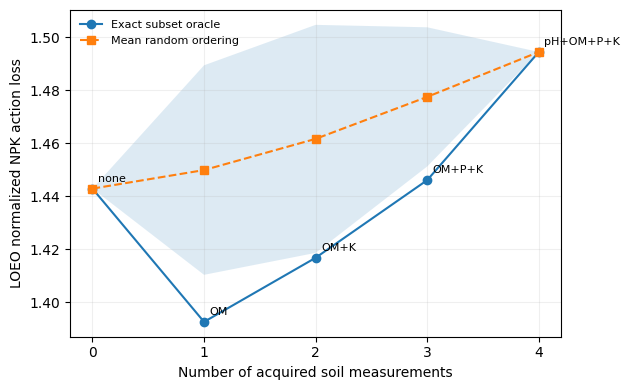

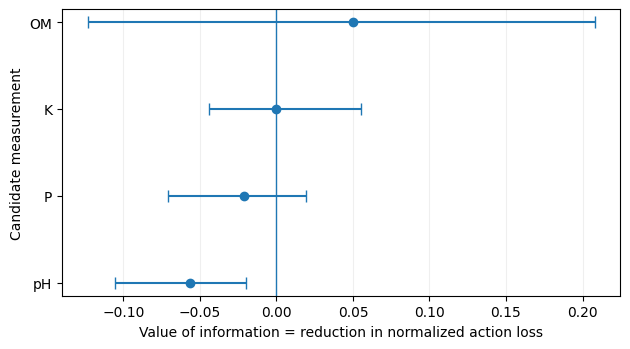

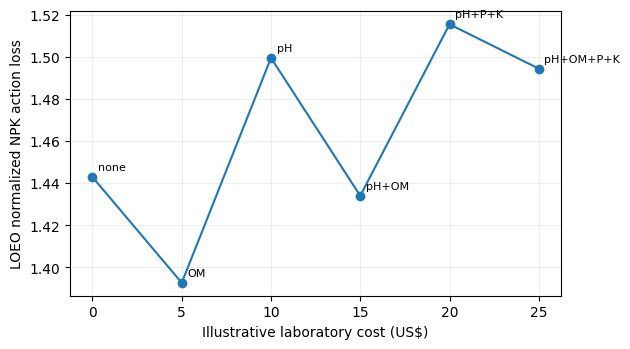

{
  "n_environments": 18,
  "baseline_context": [
    "Irr",
    "Trim",
    "Driv"
  ],
  "ridge_alpha": 10.0,
  "baseline_loss": 1.442895927136219,
  "best_singleton": "OM",
  "best_singleton_loss": 1.392692878617964,
  "best_singleton_improvement_pct": 3.4793256792882654,
  "best_singleton_voi": 0.050203048518254904,
  "best_singleton_ci95": [
    -0.12349224230423884,
    0.20793034383501116
  ],
  "best_singleton_positive_env_fraction": 0.5,
  "best_two_subset": "OM+K",
  "best_two_loss": 1.4168407144005188,
  "full_loss": 1.4943754130370157,
  "full_vs_best_singleton_degradation_pct": 7.301145570583816,
  "full_vs_baseline_change_pct": -3.5677892585760107,
  "cost_budget_cases": 2612,
  "greedy_exact_oracle_fraction": 0.97052067381317,
  "greedy_mean_regret": 1.7594410429806154e-05,
  "greedy_max_regret": 0.0005968389615929048,
  "oracle_unspent_budget_fraction": 0.7871362940275651,
  "oracle_subset_distribution": {
    "OM": 0.7745022970903522,
    "none": 0.19601837672281777,
 

In [7]:
# Figure 1: exact decision-loss frontier versus mean random order.
fig, ax = plt.subplots(figsize=(6.4, 4.0))
ax.plot(oracle.k, oracle.loss_mean, marker="o", label="Exact subset oracle")
ax.plot(random_order.k, random_order.loss_mean, marker="s", linestyle="--", label="Mean random ordering")
ax.fill_between(
    random_order.k,
    random_order.loss_mean - random_order.loss_sd,
    random_order.loss_mean + random_order.loss_sd,
    alpha=.15,
)
for _, row in oracle.iterrows():
    ax.annotate(row.subset, (row.k, row.loss_mean), xytext=(4, 5), textcoords="offset points", fontsize=8)
ax.set_xlabel("Number of acquired soil measurements")
ax.set_ylabel("LOEO normalized NPK action loss")
ax.set_xticks(range(5))
ax.legend(frameon=False, fontsize=8)
ax.grid(alpha=.2)
fig.tight_layout()
fig.savefig(FIGURES / "figure1_frontier.png", dpi=300)
fig.savefig(FIGURES / "figure1_frontier.pdf")
plt.show()

# Figure 2: singleton VOI and paired bootstrap intervals.
v = voi.set_index("measurement").loc[["OM", "K", "P", "pH"]].reset_index()
y = np.arange(len(v))
means = v.mean_voi.to_numpy()
low = means - v.ci_low.to_numpy()
high = v.ci_high.to_numpy() - means
fig, ax = plt.subplots(figsize=(6.4, 3.6))
ax.errorbar(means, y, xerr=np.vstack([low, high]), fmt="o", capsize=4)
ax.axvline(0, linewidth=1)
ax.set_yticks(y, v.measurement)
ax.invert_yaxis()
ax.set_xlabel("Value of information = reduction in normalized action loss")
ax.set_ylabel("Candidate measurement")
ax.grid(axis="x", alpha=.2)
fig.tight_layout()
fig.savefig(FIGURES / "figure2_singleton_voi.png", dpi=300)
fig.savefig(FIGURES / "figure2_singleton_voi.pdf")
plt.show()

# Supplementary laboratory-menu figure.
fig, ax = plt.subplots(figsize=(6.4, 3.6))
ax.plot(menu.cost_usd, menu.loss_mean, marker="o")
for _, row in menu.iterrows():
    ax.annotate(row.subset, (row.cost_usd, row.loss_mean), xytext=(4, 5), textcoords="offset points", fontsize=8)
ax.set_xlabel("Illustrative laboratory cost (US$)")
ax.set_ylabel("LOEO normalized NPK action loss")
ax.grid(alpha=.2)
fig.tight_layout()
fig.savefig(FIGURES / "figureS1_lab_cost_menu.png", dpi=300)
fig.savefig(FIGURES / "figureS1_lab_cost_menu.pdf")
plt.show()

best_singleton = oracle.loc[oracle.k.eq(1), "subset"].iloc[0]
best_two = oracle.loc[oracle.k.eq(2), "subset"].iloc[0]
full_key = "pH+OM+P+K"
best_row = voi.loc[voi.measurement.eq(best_singleton)].iloc[0]

PAPER_RESULTS = {
    "n_environments": len(df),
    "baseline_context": BASE,
    "ridge_alpha": ALPHA,
    "baseline_loss": base_loss,
    "best_singleton": best_singleton,
    "best_singleton_loss": loss_map[best_singleton],
    "best_singleton_improvement_pct": 100 * (base_loss - loss_map[best_singleton]) / base_loss,
    "best_singleton_voi": best_row.mean_voi,
    "best_singleton_ci95": [best_row.ci_low, best_row.ci_high],
    "best_singleton_positive_env_fraction": best_row.positive_env_fraction,
    "best_two_subset": best_two,
    "best_two_loss": loss_map[best_two],
    "full_loss": loss_map[full_key],
    "full_vs_best_singleton_degradation_pct": 100 * (loss_map[full_key] - loss_map[best_singleton]) / loss_map[best_singleton],
    "full_vs_baseline_change_pct": 100 * (base_loss - loss_map[full_key]) / base_loss,
    "cost_budget_cases": len(cost_results),
    "greedy_exact_oracle_fraction": float((cost_results.regret <= 1e-12).mean()),
    "greedy_mean_regret": float(cost_results.regret.mean()),
    "greedy_max_regret": float(cost_results.regret.max()),
    "oracle_unspent_budget_fraction": float((cost_results.oracle_cost < cost_results.budget - 1e-12).mean()),
    "oracle_subset_distribution": cost_results.oracle_subset.value_counts(normalize=True).to_dict(),
}
with open(RESULTS / "paper_quantities.json", "w") as f:
    json.dump(PAPER_RESULTS, f, indent=2)

# Assertions corresponding to manuscript claims.
assert len(subset_results) == 16
assert best_singleton == "OM"
assert best_two == "OM+K"
assert loss_map[full_key] > base_loss > loss_map[best_singleton]
assert len(cost_results) == 2612
assert abs((cost_results.regret <= 1e-12).mean() - 0.97052067381317) < 1e-12
assert abs((cost_results.oracle_cost < cost_results.budget - 1e-12).mean() - 0.7871362940275651) < 1e-12
assert best_row.ci_low < 0 < best_row.ci_high
assert (cost_results.oracle_subset == "P+K").sum() == 77

print(json.dumps(PAPER_RESULTS, indent=2))
print("ALL CORE ASSERTIONS PASSED")